# CIFAKE robustness, two architectures

Our question is whether training-time corruption augmentation buys robustness that transfers to a corruption the model never saw, and whether ImageNet pretraining changes the answer. We train a small CNN and a pretrained ResNet-18 on CIFAKE (real CIFAR-10 photographs against Stable Diffusion fakes), augment half the runs with Gaussian noise and JPEG compression, and evaluate everything on Gaussian blur, which no model ever trains on.

The headline, over seeds 42 to 44 on the 20,000-image test split. Augmentation lifts held-out blur accuracy by 0.10 to 0.22 depending on severity and architecture, at no clean cost (BaselineCNN 0.9442 to 0.9491 clean, ResNet-18 0.9693 to 0.9732). Pretraining buys clean accuracy but not robustness; the unaugmented ResNet-18 collapses harder under corruption than the unaugmented CNN.

To reproduce the analysis, run every cell top to bottom on a fresh kernel with `run_training = False` (the default). That path validates and loads the 12 saved run bundles from `results/` (about ten seconds on our laptop, dominated by the six 44 MB checkpoint loads) and retrains nothing. Setting `run_training = True` retrains only the CNN half; the ResNet-18 bundles were trained by `resnet18_runner_COLAB.ipynb` on a Colab GPU and this notebook only loads them.


In [1]:
import os
import sys
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.io import encode_jpeg, decode_jpeg
import torchvision.transforms.functional as TF
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix)
from torch.utils.data import DataLoader, random_split, Subset

In [2]:
#Run training set to false here by default. Set to true to retrain from scratch
run_training = False

In [3]:
#kagglehub caches under ~/.cache/kagglehub, so after the first download this
#returns the same local path instantly. DATA_ROOT is needed for evaluation as
#well as training, so discovery sits outside the run_training gate.
try:
  import kagglehub
except ModuleNotFoundError as err:
  raise ModuleNotFoundError(
    "kagglehub is not installed in this environment. "
    "Install it with: pip install kagglehub") from err

DATA_ROOT = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")
print(f"data root = {DATA_ROOT}")

data root = /Users/wmckie/.cache/kagglehub/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/versions/3


In [4]:
#CIFAKE ships 100k train and 20k test images split evenly between REAL and
#FAKE. Counting the files catches a partial or stale download before a long
#run wastes hours on the wrong data.
from pathlib import Path

for split, per_class in [("train", 50000), ("test", 10000)]:
  for cls in ["REAL", "FAKE"]:
    n = len(list(Path(DATA_ROOT, split, cls).glob("*.jpg")))
    assert n == per_class, f"{split}/{cls} has {n} images, expected {per_class}"
    print(f"{split}/{cls}: {n} images")

#ImageFolder indexes classes alphabetically, so FAKE comes back as 0 and REAL
#as 1. The flip below is the same one get_dataloaders applies, making fake
#detection the positive class (LABEL_FAKE = 1).
probe = torchvision.datasets.ImageFolder(
  Path(DATA_ROOT, "test"), target_transform=lambda y: 1 - y)
assert probe.class_to_idx == {"FAKE": 0, "REAL": 1}

i_real = probe.targets.index(1) #first REAL file; raw label 1 before the flip
assert probe[0][1] == 1 and probe[i_real][1] == 0
print(f"labels after flip: FAKE = {probe[0][1]}, REAL = {probe[i_real][1]}")

train/REAL: 50000 images
train/FAKE: 50000 images
test/REAL: 10000 images


test/FAKE: 10000 images
labels after flip: FAKE = 1, REAL = 0


## Data and protocol

CIFAKE pairs 60,000 real images (CIFAR-10) with 60,000 synthetic images generated by Stable Diffusion v1.4, split into 100,000 training and 20,000 test images with the classes balanced everywhere. The cell above counts every file so a partial download fails loudly, and we flip the folder labels so FAKE = 1, making the fake class the positive one that precision, recall and F1 describe.

Every run is scored on the same 16 evaluation conditions. Clean, five Gaussian noise severities, five JPEG qualities and five Gaussian blur severities, with levels taken from Hendrycks and Dietterich's CIFAR-10-C code. Noise and JPEG are the training-time augmentations for the robust strategy; blur is never trained on by any model, so the blur rows measure transfer rather than memorised invariance. Each training run carves a seeded 90/10 train/validation split and early-stops on clean validation loss, the tuning discipline the week 3 lecture assigns to the validation set, so the test split is touched exactly once per finished model.


In [5]:
LABEL_REAL = 0
LABEL_FAKE = 1


#Corruption levels. From Hendryks and Dietterich (2019),
#CIFAR-10-C: https://github.com/hendrycks/robustness/blob/master/ImageNet-C/create_c/make_cifar_c.py
#Source: robustness/ImageNet-C/create_c/make_cifar_c.py, the 32x32 version,

SEVERITIES = {
  "noise": [0.04, 0.06, 0.08, 0.09, 0.10],   #Gaussian sigma
  "blur":  [0.4, 0.6, 0.7, 0.8, 1.0],        #Gaussian sigma
  "jpeg":  [80, 65, 58, 50, 40],             #JPEG quality
}


#Hendrycks & Dietterich hold out four corruptions as a validation set so that
#methods are not tuned on what they are scored against. Same idea is used here by
#augmenting on AUGMENT_KINDS only, and report generalisation on HELDOUT_KINDS
#so that the model is tested with a corruption type it hasnt been trained on.
AUGMENT_KINDS = ["noise", "jpeg"]
HELDOUT_KINDS = ["blur"]


CONDITIONS = [("none", 0.0)] + [
  (kind, sev) for kind, levels in SEVERITIES.items() for sev in levels
]


#Standard statistics for CIFAR-10 RGB channels which CIFAKE is made from.
NORM_MEAN = (0.4914, 0.4822, 0.4465)
NORM_STD = (0.2470, 0.2435, 0.2616)

def get_device():
  """Select the best available accelerator, otherwise fall back to CPU."""
  if torch.cuda.is_available():
    return torch.device("cuda")
  if torch.backends.mps.is_available():
    return torch.device("mps")  #Apple silicon; the local runs use this, Colab uses cuda
  return torch.device("cpu")


DEVICE = get_device()


is_seed_set = False #train() checks this so an unseeded, unreproducible run shows a warning


def set_seed(seed, deterministic=True):
  """
  Seed every random number generator. Call at start of each experiment.

  deterministic=True also restricts cuDNN to use convolution algorithms
  that give same results every time. Without it, GPU adds numbers up slightly
  differently between runs so results differ in the 4th decimal place. Costs speed
  for sake of reproducibility.
  """
  global is_seed_set #ensures global is_seed_set gets set to true when called.
  is_seed_set = True
  random.seed(seed) #python's random
  np.random.seed(seed) #numpy's random
  torch.manual_seed(seed) #pytorch CPU random
  torch.cuda.manual_seed_all(seed) #pytorch GPU random
  torch.backends.cudnn.deterministic = deterministic
  torch.backends.cudnn.benchmark = not deterministic #benchmarking picks algorithms per-run, which reintroduces variation. stop this



def flip_label(y):
  #Module level, not a closure. DataLoader workers on macOS start via spawn and
  #cannot pickle a nested function; Colab's fork start method hid this.
  return 1 - y #CIFAKE labels conversely to set up so flip value.


def get_dataloaders(seed, batch_size=128, val_frac=0.1, num_workers=None):
  """
  Loads CIFAKE and returns the train, validation and test loaders.

  The same seed always gives the same train/val split, so our numbers are
  directly comparable. Images come back as raw values between 0 and 1 and are
  not normalised here, because corruption has to be applied first.
  """
  if num_workers is None:
    #Linux forks workers, so they inherit notebook definitions. macOS and
    #Windows spawn fresh processes that cannot import notebook functions, so
    #loading stays in-process there.
    num_workers = 2 if sys.platform.startswith("linux") else 0

  to_tensor = transforms.ToTensor()

  #Sub folders within CIFAKE's train and test folders used as classes
  full_train = torchvision.datasets.ImageFolder(
    os.path.join(DATA_ROOT, "train"), #where to look
    transform=to_tensor, #turning each image to tensore
    target_transform=flip_label, #changing the labels
  )

  test_set = torchvision.datasets.ImageFolder(
    os.path.join(DATA_ROOT, "test"),
    transform=to_tensor,
    target_transform=flip_label,
  )

  #10% from training set for validation.
  n_val = int(len(full_train) * val_frac)
  n_train = len(full_train) - n_val
  train_set, val_set = random_split(
    full_train, [n_train, n_val],
    generator=torch.Generator().manual_seed(seed),
  )

  train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
  val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
  test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

  return train_loader, val_loader, test_loader


def normalise(images):
  """Channel normarlisation for after corrupt."""
  return TF.normalize(images, NORM_MEAN, NORM_STD)


def corrupt(images, kind, severity):
  """
  Apply a degradation type to a batch.

  images   : the batch
  kind     : "none", "blur", "noise" or "jpeg"
  severity : sigma (blur), sigma (noise), or quality (jpeg, lower = worse)

  Returns a new batch without altering the input.
  """
  #Clean condition:
  if kind == "none" or severity is None:
    return images

  #Augmented conditions
  if kind == "blur":
    k = int(2 * np.ceil(3 * severity) + 1)
    return TF.gaussian_blur(images, kernel_size=[k, k], sigma=[severity, severity])

  if kind == "noise":
    noisy = images + torch.randn_like(images) * severity #Nudges every pixel slightly up/ down to create noise
    return noisy.clamp(0.0, 1.0) #forces everything back to valid range.

  if kind == "jpeg":
    #encode_jpeg needs uint8 CHW tensors on CPU, one image at a time.
    device = images.device
    as_uint8 = (images.clamp(0, 1) * 255).to(torch.uint8).cpu() #JPEG works on whole numbers not decimals. multiply by 255 and convert to 8 bit ints. move to cpu for JPEG encoder.
    out = torch.stack([
      decode_jpeg(encode_jpeg(img, quality=int(severity)))
      for img in as_uint8
    ])

    return (out.float() / 255.0).to(device) #convert back to decimals

  raise ValueError(f"Unknown corruption kind: {kind}")


def augment_batch(images, kinds=None, rng=None, n_chunks=8):
  """
  Corrupts training images so the model learns not to depend on clean images.

  50% chance of image being flipped horizontally. Batch is split into chunks,
  each getting its own random corruption at a random severity, so each batch
  contains a mixture of degradtions.

  """

  if rng is None:
    rng = random

  if kinds is None:
    kinds = AUGMENT_KINDS

  n = images.size(0)
  out = images.clone() #Prevents altering input tensor

  flip = torch.rand(n, device=images.device) < 0.5 #Flips image half of the time
  out[flip] = torch.flip(out[flip], dims=[3])

  #Shuffle image indices and split into 8 groups, each with random corruption.
  #Ensures a batch has a mixture of corruption types.
  perm = torch.randperm(n)
  for chunk in torch.chunk(perm, min(n_chunks, n)):
    kind = rng.choice(kinds)
    severity = rng.choice(SEVERITIES[kind])
    out[chunk] = corrupt(out[chunk], kind, severity)
  return out



DEFAULT_CONFIG = {
  "lr": 1e-3,
  "weight_decay": 0.0,
  "max_epochs": 30,
  "patience": 5,
  "augment": False,
  "optimiser": "adam", #"sgd" also available if we want to compare optimisers
  "augment_kinds": list(AUGMENT_KINDS),
  "val_mode": "match", #"match" = validate on the same distribution as train on. "clean" = always validate on clean images.
}


def train(model, train_loader, val_loader, config=None, verbose=True):
  """
  Trains a model, stopping early if validation loss stops improving.

  Ensures any difference in results for baseline and pre-trained models comes
  from the model, not from how it was trained. anything that gets varied goes
  in config.

  Returns the trained model and a history dict with the loss curves, number of
  epochs, best epoch, and the config used.
  """
  #Passed in config with defaults filled for what is left out.
  cfg = DEFAULT_CONFIG.copy()
  if config is not None:
    cfg.update(config)

  if not is_seed_set:
    print("WARNING: set_seed() has not been called. This run is not reproducible.")

  model = model.to(DEVICE)
  criterion = nn.CrossEntropyLoss()

  if cfg["optimiser"] == "adam":
    optimiser = torch.optim.Adam(
      model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])

  elif cfg["optimiser"] == "sgd":
    optimiser = torch.optim.SGD(
      model.parameters(), lr=cfg["lr"], momentum=0.9,
      weight_decay=cfg["weight_decay"])

  else:
    raise ValueError(f"Unknown optimiser: {cfg['optimiser']}")

  #keep track of the best version of the model so far
  best_loss = float("inf")
  best_state = copy.deepcopy(model.state_dict())
  best_epoch = 0
  epochs_since_improvement = 0
  train_losses = []
  val_losses = []

  for epoch in range(1, cfg["max_epochs"] + 1):
    model.train()
    running = 0.0

    for images, labels in train_loader:
      images, labels = images.to(DEVICE), labels.to(DEVICE)

      if cfg["augment"]:
        images = augment_batch(images, cfg["augment_kinds"])

      images = normalise(images) #Always after corruption

      optimiser.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimiser.step()
      running += loss.item() * images.size(0)

    train_loss = running / len(train_loader.dataset)

    #If model trains with augmentation and val_mode is "match",
    #the validation images also get corrupted, so model gets judged
    #on the kind of data it's trained for.
    val_augment = cfg["augment"] and cfg["val_mode"] == "match"

    model.eval()

    running = 0.0

    val_rng = random.Random(12345) #Which corruptions, same every epoch

    #The noise corruption calls torch.randn_like, which uses torch's generator
    #which also needs seeding so the noise values dont change each epoch.
    #Save the current state first so training's randomness can be put back afterwards.

    torch_state = torch.get_rng_state()

    if val_augment:
      torch.manual_seed(12345)


    with torch.no_grad():

      for images, labels in val_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        if val_augment:
          images = augment_batch(images, cfg["augment_kinds"], rng=val_rng)

        images = normalise(images)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running += loss.item() * images.size(0)

    torch.set_rng_state(torch_state) #Put training's randomness back how it was
    val_loss = running / len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if verbose:
      print(f"epoch {epoch:2d}  train {train_loss:.4f}  val {val_loss:.4f}")

    #Save weights if improved and reset counter. If 5 epochs happen without improvement it stops to prevent overfitting
    if val_loss < best_loss:
      best_loss = val_loss
      best_epoch = epoch
      best_state = copy.deepcopy(model.state_dict())
      epochs_since_improvement = 0

    else:
      epochs_since_improvement += 1

      if epochs_since_improvement >= cfg["patience"]:
        if verbose:
          print(f"early stop at epoch {epoch} (best was {best_epoch})")
        break

  model.load_state_dict(best_state)  #always return the best, not the last

  history = {
    "epochs_run": len(train_losses),
    "best_epoch": best_epoch,
    "best_val_loss": best_loss,
    "train_losses": train_losses,
    "val_losses": val_losses,
    "config": cfg, #the merged config actually used, so defaults get recorded too
  }

  return model, history


def evaluate(model, loader, kind="none", severity=0.0):
  """
  Tests a model on one corruption condition and returns accuracy, precision,
  recall, F1 and ROC-AUC.
  """
  model = model.to(DEVICE).eval()

  #Collect results batch by batch, then combine at the end
  all_probs = []
  all_preds = []
  all_labels = []

  with torch.no_grad(): #No gradients needed, nothing is being trained
    for images, labels in loader:
      images = images.to(DEVICE)
      images = corrupt(images, kind, severity) #corrupt before normalising
      images = normalise(images)
      outputs = model(images)
      probs = torch.softmax(outputs, dim=1)[:, LABEL_FAKE] #keep probability of being fake.

      all_probs.append(probs.cpu())
      all_preds.append(outputs.argmax(dim=1).cpu())
      all_labels.append(labels)

  #Join the per batch lists into one array each and convert to numpy
  y_prob = torch.cat(all_probs).numpy()
  y_pred = torch.cat(all_preds).numpy()
  y_true = torch.cat(all_labels).numpy()

  #pos_label=LABEL_FAKE means precision, recall and F1 are all measured with
  #respect to detecting fakes. zero_division=0 stops it erroring during division
  #if the model never predicts fake.
  return {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, pos_label=LABEL_FAKE, zero_division=0),
    "recall": recall_score(y_true, y_pred, pos_label=LABEL_FAKE, zero_division=0),
    "f1": f1_score(y_true, y_pred, pos_label=LABEL_FAKE, zero_division=0),
    "roc_auc": roc_auc_score(y_true, y_prob)
  }



def evaluate_all_conditions(model, test_loader, model_name, strategy, seed,
        config, history):
  """
  Runs a trained model through every corruption condition and returns all the
  results as one dataframe.
  """
  rows = []

  for kind, severity in CONDITIONS:
    metrics = evaluate(model, test_loader, kind, severity)

    rows.append({
      "model": model_name,
      "strategy": strategy,
      "corruption": kind,
      "severity": severity,
      "seed": seed,
      "accuracy": metrics["accuracy"],
      "precision": metrics["precision"],
      "recall": metrics["recall"],
      "f1": metrics["f1"],
      "roc_auc": metrics["roc_auc"],
      "epochs_run": history["epochs_run"],
      "best_epoch": history["best_epoch"],
      "lr": config["lr"],
      "augment": config["augment"],
    })

    print(f"{kind} {severity}  acc {metrics['accuracy']:.4f}  auc {metrics['roc_auc']:.4f}")

  return pd.DataFrame(rows)


def make_small_loader(loader, n=512, batch_size=64):
  """
  Cuts a loader down to n random samples for quick testing.

  Has to be random rather than the first n. ImageFolder puts all the FAKE
  images before the REAL ones, so taking a slice off the front would give a
  single class and roc_auc_score would throw an error.
  """
  #randperm shuffles all the image positions, then we keep the first n
  idx = torch.randperm(len(loader.dataset))[:n].tolist()

  #Subset wraps the original dataset but only exposes those n images
  return DataLoader(Subset(loader.dataset, idx), batch_size=batch_size)


def smoke_test():
  """
  Quick end to end check. one epoch on 512 images, then every condition.
  """
  set_seed(42) #house seed, same as the main runs
  train_loader, val_loader, test_loader = get_dataloaders(seed=42, batch_size=64)
  train_loader = make_small_loader(train_loader)
  val_loader = make_small_loader(val_loader)
  test_loader = make_small_loader(test_loader)

  model = BaselineCNN()

  model, history = train(model, train_loader, val_loader,
             {"max_epochs": 1, "patience": 1})

  #NaN loss here means a broken pipeline, not a bad model. Catch it now.
  assert np.isfinite(history["train_losses"]).all()
  assert np.isfinite(history["val_losses"]).all()

  print("\nresults:")
  df = evaluate_all_conditions(model, test_loader, "smoke_cnn", "baseline", 42,
             history["config"], history)

  return df

## Architectures

BaselineCNN is the week 4 lab architecture widened for 3-channel 32x32 input, 544,066 parameters. We kept it deliberately small; the question is about training strategy, and a small model makes the paired comparison cheap enough to run three seeds locally.

ResNet-18 answers the marker's ask for a wider range of architectures and brings in the transfer learning we met in the week 5 lab. We start from ImageNet-pretrained weights, swap the stock 7x7 stride-2 stem for the 3x3 stride-1 convolution He et al. (2016, section 4.2) use for their own CIFAR-10 networks (the stock stem would shrink a 32x32 image 4x before the first residual block), drop the max-pool, and fit a fresh two-class head, 11,169,858 parameters in total. The one training departure from the CNN recipe is the learning rate, 1e-4 rather than 1e-3, because fine-tuning pretrained weights at 1e-3 tears up the ImageNet features before they can help. Two limitations carry to the report. The stem swap discards the pretrained conv1 weights, and we keep CIFAR-style normalisation statistics rather than ImageNet's, so the pretrained layers see slightly shifted inputs.


In [6]:
import torch.nn.functional as F

class BaselineCNN(nn.Module):
  """
  Baseline CNN for CIFAKE real vs fake classification.

  The week 4 lab architecture, widened for 3-channel 32x32 input:
    Conv1(3->32, 3x3, pad=1) -> ReLU -> MaxPool(2x2)
    Conv2(32->64, 3x3, pad=1) -> ReLU -> MaxPool(2x2)
    Flatten -> FC1(4096->128) -> ReLU -> FC2(128->2)
  """

  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    #two 2x2 pools take 32 -> 16 -> 8, so the flattened length is 64 * 8 * 8 = 4096
    self.fc1 = nn.Linear(64 * 8 * 8, 128)
    self.fc2 = nn.Linear(128, 2)

  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))  # -> (batch, 32, 16, 16)
    x = self.pool(F.relu(self.conv2(x)))  # -> (batch, 64, 8, 8)
    x = torch.flatten(x, 1)
    x = F.relu(self.fc1(x))
    return self.fc2(x)  #logits; CrossEntropyLoss applies the softmax


out = BaselineCNN()(torch.zeros(2, 3, 32, 32))
assert out.shape == (2, 2)  #two classes; the fc sizes are built against this input

In [7]:
def build_resnet18_cifar(pretrained=False):
  """ResNet-18 with the stem adapted for 32x32 input.

  Identical to build_resnet18_cifar in resnet18_runner_COLAB.ipynb, which
  trained the saved bundles: 3x3 stride-1 conv with no max-pool (the stem He
  et al., 2016, section 4.2, use for their CIFAR-10 networks, because the
  stock 7x7 stride-2 stem would collapse a 32x32 image 4x before the first
  residual block), plus a fresh two-class head. Default pretrained=False
  because this notebook only loads finished checkpoints; building the bare
  architecture skips a 45 MB ImageNet weight download that the loaded state
  dict would immediately overwrite.
  """
  model = torchvision.models.resnet18(weights="DEFAULT" if pretrained else None)

  model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
  model.maxpool = nn.Identity()
  model.fc = nn.Linear(512, 2)

  #Frozen stem, asserted so a drive-by edit cannot silently change the protocol.
  assert isinstance(model.conv1, nn.Conv2d)
  assert model.conv1.kernel_size == (3, 3)
  assert model.conv1.stride == (1, 1)
  assert model.conv1.padding == (1, 1)
  assert model.conv1.bias is None
  assert isinstance(model.maxpool, nn.Identity)
  assert model.fc.out_features == 2 and model.fc.in_features == 512
  return model


resnet_param_count = sum(p.numel() for p in build_resnet18_cifar().parameters())
cnn_param_count = sum(p.numel() for p in BaselineCNN().parameters())
print(f"resnet18 parameters = {resnet_param_count:,}")
print(f"baseline cnn parameters = {cnn_param_count:,}")


resnet18 parameters = 11,169,858
baseline cnn parameters = 544,066


In [8]:
#One epoch on 512 images to prove the whole pipeline holds together before
#committing hours to the real runs.
smoke_df = smoke_test()

metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]
assert smoke_df.shape[0] == 16  #clean condition plus 3 corruption types x 5 severities
assert smoke_df[metric_cols].notna().all().all()
assert ((smoke_df[metric_cols] >= 0) & (smoke_df[metric_cols] <= 1)).all().all()
print("smoke test passed: 16 conditions, all metrics in [0, 1]")
print("pipeline validation only. one epoch on 512 images, none of these numbers are reportable results")

epoch  1  train 0.6711  val 0.6277

results:
none 0.0  acc 0.6445  auc 0.7256
noise 0.04  acc 0.6367  auc 0.7145
noise 0.06  acc 0.6230  auc 0.7085
noise 0.08  acc 0.6230  auc 0.6974


noise 0.09  acc 0.6191  auc 0.6942
noise 0.1  acc 0.6230  auc 0.6913
blur 0.4  acc 0.6406  auc 0.7182
blur 0.6  acc 0.6191  auc 0.6962


blur 0.7  acc 0.6113  auc 0.6881
blur 0.8  acc 0.6113  auc 0.6820
blur 1.0  acc 0.6055  auc 0.6724
jpeg 80  acc 0.6445  auc 0.7228


jpeg 65  acc 0.6484  auc 0.7243
jpeg 58  acc 0.6406  auc 0.7255
jpeg 50  acc 0.6348  auc 0.7198
jpeg 40  acc 0.6504  auc 0.7199
smoke test passed: 16 conditions, all metrics in [0, 1]
pipeline validation only. one epoch on 512 images, none of these numbers are reportable results


## Experiment matrix

Two strategies per architecture, baseline (no augmentation) and robust (noise plus JPEG augmentation), over paired seeds 42, 43 and 44. Pairing means both strategies at a seed share the identical data split and initial weights, so each seed yields a within-pair gap rather than two independent draws. The orchestration below never retrains when a saved bundle passes its checks; a bundle must carry the exact frozen config, recognised dataset provenance, all 16 conditions and a checkpoint that loads strictly back into its architecture, or it is rejected with a printed reason.

The two halves trained on different hardware. The CNN runs came from a local Apple-silicon GPU (86 to 265 seconds per run); the ResNet-18 runs came from a Colab Tesla T4 driven by `resnet18_runner_COLAB.ipynb` (679 to 1302 seconds per run), which published each bundle atomically into `results/` under a `resnet18_` prefix. Hardware changes wall time, not the protocol; every ResNet-18 history records its environment beside the run.


In [9]:
import json
import pickle
import time

#Experiment matrix. The two strategies share every setting except augment, so
#any gap in the results is the augmentation and nothing else.
SEEDS = [42, 43, 44]  #three draws; one seed cannot separate signal from noise

EXPERIMENT_CONFIG = {
  "lr": 1e-3,
  "weight_decay": 0.0,
  "max_epochs": 30,
  "patience": 5,
  "optimiser": "adam",
  "augment_kinds": list(AUGMENT_KINDS),
  "val_mode": "clean",  #both strategies early-stop against the same clean validation set, so epoch budgets are comparable
}

STRATEGIES = {
  "baseline": {"augment": False},
  "robust": {"augment": True},
}

#Guard the pairing: strategies may differ in augment and nothing else, and the
#robust model must never train on blur, or the held-out comparison is void.
assert all(set(o) == {"augment"} for o in STRATEGIES.values())
assert AUGMENT_KINDS == ["noise", "jpeg"] and HELDOUT_KINDS == ["blur"]
assert set(AUGMENT_KINDS).isdisjoint(HELDOUT_KINDS)

RESULTS_DIR = "results"
METRIC_COLS = ["accuracy", "precision", "recall", "f1", "roc_auc"]
VAL_FRAC = 0.1  #90/10 train/val split, fixed across every run

#Recorded dataset identity, written into any new run's history. kagglehub
#paths end in versions/N, so a saved run carries which CIFAKE release and
#split produced it. check_saved_run accepts the two identities the finished
#runs actually recorded (release 3 from local kagglehub, "unversioned" from
#the Colab Kaggle mount, both the published CIFAKE data) and rejects anything
#else instead of silently mixing data sources.
KNOWN_CIFAKE_VERSIONS = {"3", "unversioned"}
DATASET_META = {
  "cifake_version": os.path.basename(DATA_ROOT),
  "val_frac": VAL_FRAC,
}
if DATASET_META["cifake_version"] not in KNOWN_CIFAKE_VERSIONS:
  print(f"warning: kagglehub resolved release {DATASET_META['cifake_version']!r}; "
      "saved bundles still load, but a retrain would record this new release "
      "and be rejected as unrecognised provenance next session.")


def run_paths(strategy, seed, prefix=""):
  """Deterministic artefact names so a fresh session can find every run.
  prefix="" is the CNN bundles; the ResNet-18 bundles sit under resnet18_."""
  stem = f"{prefix}{strategy}_seed{seed}"
  return (os.path.join(RESULTS_DIR, f"{stem}.pt"),
      os.path.join(RESULTS_DIR, f"{stem}_history.json"),
      os.path.join(RESULTS_DIR, f"{stem}_results.csv"))


def check_saved_run(strategy, seed, expected_config, model_name="BaselineCNN",
          model_builder=None, prefix=""):
  """Accept a saved run only if the full bundle is present and consistent.
  Returns (results dataframe, None) on acceptance or (None, reason) on rejection.
  The defaults keep every CNN call site unchanged; the ResNet-18 cells pass
  their own model name, builder and artefact prefix."""
  if model_builder is None:
    model_builder = BaselineCNN
  ckpt_path, hist_path, csv_path = run_paths(strategy, seed, prefix)

  #All three or nothing. A checkpoint without its CSV means the run died
  #mid-evaluation and has to be redone.
  missing = [p for p in (ckpt_path, hist_path, csv_path) if not os.path.exists(p)]
  if missing:
    return None, f"missing {', '.join(os.path.basename(p) for p in missing)}"

  try:
    with open(hist_path) as f:
      history = json.load(f)
  except (json.JSONDecodeError, OSError) as err:
    return None, f"unreadable history ({err})"

  #The saved config must match what this session would run, otherwise the
  #artefact belongs to an older protocol and silently poisons the comparison.
  saved = history.get("config", {})
  drift = {k: (saved.get(k), v) for k, v in expected_config.items()
       if saved.get(k) != v}
  if drift:
    return None, f"config drift {drift}"

  #The run must also come from recognised data and the frozen split, not just
  #this training config. The CNN runs record release "3" (local kagglehub);
  #the ResNet runs record "unversioned" because Colab's Kaggle mount exposes
  #no version number. Both are the published CIFAKE data, so both pass; any
  #other recorded identity is unknown data and fails.
  saved_meta = history.get("dataset", {})
  if saved_meta.get("cifake_version") not in KNOWN_CIFAKE_VERSIONS:
    return None, f"unrecognised dataset provenance {saved_meta.get('cifake_version')!r}"
  if saved_meta.get("val_frac") != VAL_FRAC:
    return None, f"val_frac {saved_meta.get('val_frac')!r} is not the frozen {VAL_FRAC}"

  df = pd.read_csv(csv_path)
  if df.shape[0] != 16:
    return None, f"csv has {df.shape[0]} rows, expected 16"

  #Row count alone lets a duplicated condition hide a missing one. Compare the
  #(corruption, severity) pairs as a set against the protocol's 16.
  saved_conditions = set(zip(df["corruption"], df["severity"]))
  if saved_conditions != set(CONDITIONS):
    return None, "csv conditions do not match the 16-condition protocol"

  if not ((df["strategy"] == strategy).all() and (df["seed"] == seed).all()
      and (df["model"] == model_name).all()):
    return None, "csv strategy/seed/model does not match its filename"
  if df[METRIC_COLS].isna().any().any():
    return None, "csv has missing metric values"
  if not ((df[METRIC_COLS] >= 0) & (df[METRIC_COLS] <= 1)).all().all():
    return None, "csv metric out of [0, 1]"

  #A checkpoint that does not load back into the architecture is dead weight.
  #weights_only=True stated explicitly. it refuses arbitrary pickled code, and
  #the default has moved between torch versions so relying on it is fragile.
  try:
    model_builder().load_state_dict(
      torch.load(ckpt_path, map_location="cpu", weights_only=True))
  except (RuntimeError, OSError, KeyError, pickle.UnpicklingError) as err:
    return None, f"checkpoint does not load into {model_name} ({err})"

  return df, None


def run_experiments(seeds=None):
  """Train and evaluate every strategy x seed pair, saving as it goes.

  seeds defaults to the full protocol. Passing a subset runs the compute in
  stages (one seed per session) without touching the other seeds' artefacts.
  """
  seeds = SEEDS if seeds is None else seeds
  frames = []

  for seed in seeds:
    #Same seed for both strategies, so they train on the identical split and
    #start from identical weights. The comparison is paired, not two draws.
    for strategy, overrides in STRATEGIES.items():
      config = {**EXPERIMENT_CONFIG, **overrides}
      saved_df, reason = check_saved_run(strategy, seed, config)

      if saved_df is not None:
        print(f"{strategy} seed {seed}: complete saved run found, skipping")
        frames.append(saved_df)
        continue
      if any(os.path.exists(p) for p in run_paths(strategy, seed)):
        print(f"{strategy} seed {seed}: rejecting saved artefacts ({reason})")

      print(f"\n{strategy} seed {seed}")
      set_seed(seed)
      train_loader, val_loader, test_loader = get_dataloaders(
        seed=seed, val_frac=VAL_FRAC)
      model = BaselineCNN()  #same architecture for both strategies

      t0 = time.time()
      model, history = train(model, train_loader, val_loader, config)
      history["wall_time_s"] = round(time.time() - t0, 1)
      history["dataset"] = dict(DATASET_META)  #so resume can verify provenance

      #First artefact write is the only place the directory is needed.
      os.makedirs(RESULTS_DIR, exist_ok=True)

      ckpt_path, hist_path, csv_path = run_paths(strategy, seed)

      #Save before evaluating. A crash mid-evaluation should not cost the run.
      torch.save(model.state_dict(), ckpt_path)
      with open(hist_path, "w") as f:
        json.dump(history, f)

      df = evaluate_all_conditions(model, test_loader, "BaselineCNN", strategy,
              seed, history["config"], history)
      df.to_csv(csv_path, index=False)
      frames.append(df)

  results = pd.concat(frames, ignore_index=True)
  results.to_csv(os.path.join(RESULTS_DIR, "all_results.csv"), index=False)
  assert results.shape[0] == len(seeds) * len(STRATEGIES) * 16
  return results


if run_training:
  all_results = run_experiments()
else:
  print("run_training = False, experiments not started")

run_training = False, experiments not started


In [10]:
#The ResNet-18 bundles were trained by resnet18_runner_COLAB.ipynb on a Colab
#Tesla T4 and published under the resnet18_ prefix. This notebook never
#retrains them; it proves each bundle intact through the same gate the CNN
#bundles pass, down to a strict state-dict load into the architecture.
RESNET_CONFIG = {
  "lr": 1e-4,  #fine-tuning rate, the one departure from the CNN recipe
  "weight_decay": 0.0,
  "max_epochs": 30,
  "patience": 5,
  "optimiser": "adam",
  "augment_kinds": list(AUGMENT_KINDS),
  "val_mode": "clean",
}

resnet_frames = []
for seed in SEEDS:
  for strategy in STRATEGIES:
    config = {**RESNET_CONFIG, **STRATEGIES[strategy]}
    df, reason = check_saved_run(strategy, seed, config, model_name="ResNet18",
                   model_builder=build_resnet18_cifar,
                   prefix="resnet18_")
    assert df is not None, f"resnet18 {strategy} seed {seed} rejected: {reason}"
    resnet_frames.append(df)
    with open(run_paths(strategy, seed, "resnet18_")[1]) as f:
      h = json.load(f)
    clean_acc = df.loc[df["corruption"] == "none", "accuracy"].item()
    print(f"resnet18 {strategy} seed {seed}: {h['epochs_run']} epochs "
        f"(best {h['best_epoch']}), wall = {h['wall_time_s']:.0f}s, "
        f"clean test accuracy = {clean_acc:.3f}")

#The aggregate must be exactly the six per-run CSVs, or someone edited one
#side after publication.
resnet_results = pd.concat(resnet_frames, ignore_index=True)
resnet_agg = pd.read_csv(os.path.join(RESULTS_DIR, "resnet18_all_results.csv"))
pd.testing.assert_frame_equal(resnet_agg, resnet_results)
print(f"\nall 6 resnet18 bundles valid; aggregate matches their concatenation "
    f"({len(resnet_agg)} rows)")


resnet18 baseline seed 42: 9 epochs (best 4), wall = 936s, clean test accuracy = 0.970


resnet18 robust seed 42: 11 epochs (best 6), wall = 1026s, clean test accuracy = 0.973
resnet18 baseline seed 43: 8 epochs (best 3), wall = 679s, clean test accuracy = 0.967


resnet18 robust seed 43: 11 epochs (best 6), wall = 1026s, clean test accuracy = 0.971


resnet18 baseline seed 44: 9 epochs (best 4), wall = 764s, clean test accuracy = 0.971
resnet18 robust seed 44: 14 epochs (best 9), wall = 1302s, clean test accuracy = 0.976

all 6 resnet18 bundles valid; aggregate matches their concatenation (96 rows)


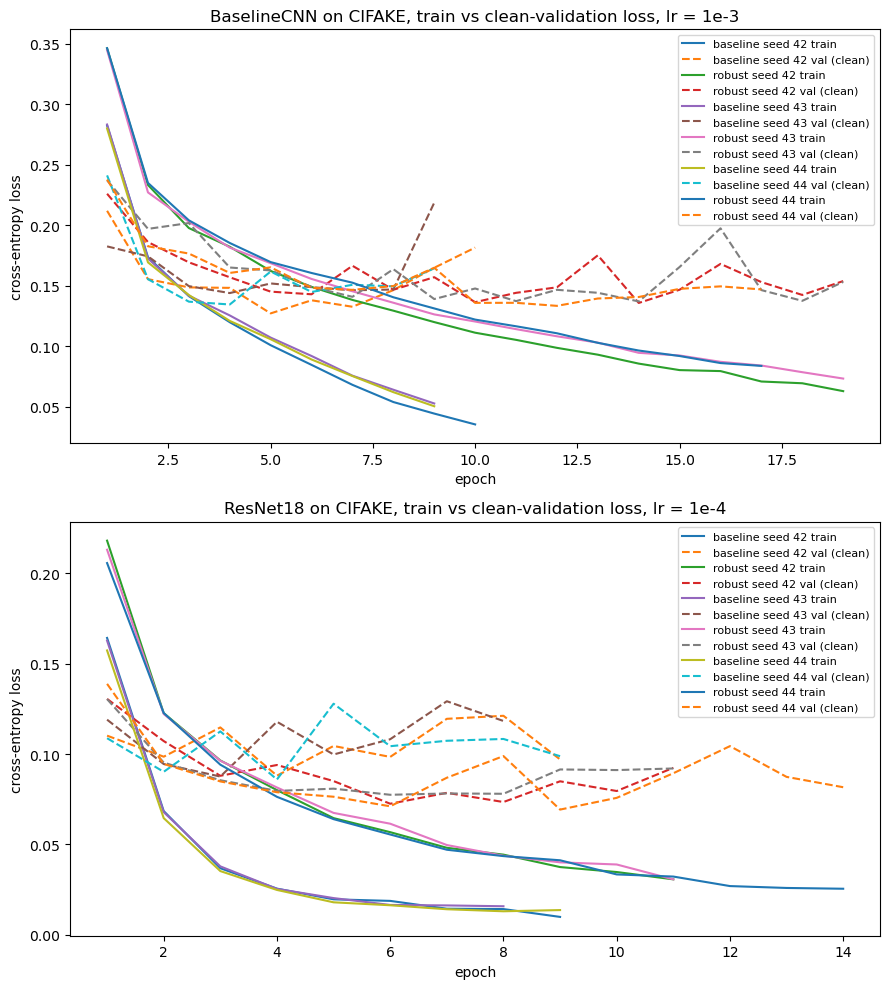

BaselineCNN baseline seed 42: stopped after 10 epochs (best epoch 5, best val loss = 0.1273, wall time = 96s)
BaselineCNN robust seed 42: stopped after 19 epochs (best epoch 14, best val loss = 0.1359, wall time = 265s)
BaselineCNN baseline seed 43: stopped after 9 epochs (best epoch 4, best val loss = 0.1440, wall time = 86s)
BaselineCNN robust seed 43: stopped after 19 epochs (best epoch 14, best val loss = 0.1371, wall time = 264s)
BaselineCNN baseline seed 44: stopped after 9 epochs (best epoch 4, best val loss = 0.1346, wall time = 87s)
BaselineCNN robust seed 44: stopped after 17 epochs (best epoch 12, best val loss = 0.1335, wall time = 237s)
ResNet18 baseline seed 42: stopped after 9 epochs (best epoch 4, best val loss = 0.0881, wall time = 936s)
ResNet18 robust seed 42: stopped after 11 epochs (best epoch 6, best val loss = 0.0726, wall time = 1026s)
ResNet18 baseline seed 43: stopped after 8 epochs (best epoch 3, best val loss = 0.0876, wall time = 679s)
ResNet18 robust seed 

In [11]:
#Loss curves come from the saved bundles, not from live training, so this
#cell works in a fresh session with run_training = False.
curve_specs = [
  ("BaselineCNN", "", EXPERIMENT_CONFIG, None, "1e-3"),
  ("ResNet18", "resnet18_", RESNET_CONFIG, build_resnet18_cifar, "1e-4"),
]

completed = []
fig, axes = plt.subplots(2, 1, figsize=(9, 10))
for ax, (model_name, prefix, base_config, builder, lr_label) in zip(axes, curve_specs):
  for seed in SEEDS:
    for strategy in STRATEGIES:
      config = {**base_config, **STRATEGIES[strategy]}
      df, reason = check_saved_run(strategy, seed, config, model_name=model_name,
                     model_builder=builder, prefix=prefix)
      if df is None:
        print(f"{model_name} {strategy} seed {seed}: no accepted bundle ({reason})")
        continue
      with open(run_paths(strategy, seed, prefix)[1]) as f:
        history = json.load(f)
      completed.append((model_name, strategy, seed, history))
      epochs = range(1, history["epochs_run"] + 1)
      ax.plot(epochs, history["train_losses"], label=f"{strategy} seed {seed} train")
      ax.plot(epochs, history["val_losses"], linestyle="--",
          label=f"{strategy} seed {seed} val (clean)")
  ax.set_xlabel("epoch")
  ax.set_ylabel("cross-entropy loss")
  ax.set_title(f"{model_name} on CIFAKE, train vs clean-validation loss, lr = {lr_label}")
  ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

for model_name, strategy, seed, h in completed:
  print(f"{model_name} {strategy} seed {seed}: stopped after {h['epochs_run']} epochs "
      f"(best epoch {h['best_epoch']}, best val loss = {h['best_val_loss']:.4f}, "
      f"wall time = {h.get('wall_time_s', float('nan')):.0f}s)")


Both panels tell the same story at different scales. The baselines overfit early; their training loss keeps falling while clean-validation loss bottoms out around epoch 4 to 5, and early stopping ends them at 9 to 10 epochs for the CNN and 8 to 9 for the ResNet-18. The robust runs train longer, 17 to 19 epochs for the CNN and 11 to 14 for the ResNet-18, because the corrupted training stream keeps the training loss honest and delays the validation minimum. That is augmentation acting as a regulariser, the overfitting mechanism from the week 3 lecture. The ResNet-18 curves also sit far lower on the loss axis (best validation loss 0.069 to 0.088 against the CNN's 0.127 to 0.144), the first sign that pretraining buys clean performance.


## Results

Every number below is test-split accuracy (20,000 images no model trained or validated on), aggregated over seeds 42 to 44 as mean plus or minus the sample standard deviation. The first table shows all 16 conditions for the four architecture and strategy combinations; the second pulls out the worst severity of each corruption with the robust-minus-baseline gap the report quotes.


In [12]:
#Same cross-check for the CNN side before the two halves are combined.
cnn_results = pd.read_csv(os.path.join(RESULTS_DIR, "all_results.csv"))
cnn_concat = pd.concat(
  [pd.read_csv(run_paths(s, seed)[2]) for seed in SEEDS for s in STRATEGIES],
  ignore_index=True)
pd.testing.assert_frame_equal(cnn_results, cnn_concat)

results = pd.concat([cnn_results, resnet_results], ignore_index=True)

stats = (results.groupby(["model", "strategy", "corruption", "severity"])
     ["accuracy"].agg(["mean", "std"]).reset_index())
stats["cell"] = stats.apply(lambda r: f"{r['mean']:.3f} +/- {r['std']:.3f}", axis=1)
pivot = stats.pivot(index=["corruption", "severity"],
          columns=["model", "strategy"], values="cell")

#Protocol order, not alphabetical: clean first, then the two augmented
#corruptions, then held-out blur last; jpeg listed from mild to harsh.
row_order = ([("none", 0.0)]
       + [("noise", float(s)) for s in SEVERITIES["noise"]]
       + [("jpeg", float(q)) for q in SEVERITIES["jpeg"]]
       + [("blur", float(s)) for s in SEVERITIES["blur"]])
pivot = pivot.reindex(row_order)
display(pivot)

#The headline table the report quotes: worst severity of each corruption,
#3-seed mean accuracy per strategy, robust minus baseline gap.
worst = [("clean", "none", 0.0), ("noise 0.1", "noise", 0.10),
     ("jpeg 40", "jpeg", 40.0), ("blur 1", "blur", 1.0)]
headline_rows = []
for model in ["BaselineCNN", "ResNet18"]:
  for name, kind, sev in worst:
    sub = results[(results["model"] == model) & (results["corruption"] == kind)
           & (results["severity"] == sev)]
    means = sub.groupby("strategy")["accuracy"].mean()
    headline_rows.append({"model": model, "condition": name,
               "baseline": round(means["baseline"], 3),
               "robust": round(means["robust"], 3),
               "gap": round(means["robust"] - means["baseline"], 3)})
display(pd.DataFrame(headline_rows))


model                    BaselineCNN                          ResNet18  \
strategy                    baseline           robust         baseline   
corruption severity                                                      
none       0.00      0.944 +/- 0.001  0.949 +/- 0.001  0.969 +/- 0.002   
noise      0.04      0.895 +/- 0.000  0.947 +/- 0.001  0.911 +/- 0.012   
           0.06      0.844 +/- 0.004  0.944 +/- 0.001  0.834 +/- 0.029   
           0.08      0.813 +/- 0.006  0.941 +/- 0.002  0.755 +/- 0.029   
           0.09      0.806 +/- 0.006  0.937 +/- 0.001  0.719 +/- 0.020   
           0.10      0.803 +/- 0.003  0.934 +/- 0.003  0.689 +/- 0.016   
jpeg       80.00     0.938 +/- 0.002  0.945 +/- 0.001  0.961 +/- 0.003   
           65.00     0.935 +/- 0.004  0.950 +/- 0.001  0.961 +/- 0.002   
           58.00     0.909 +/- 0.009  0.948 +/- 0.003  0.949 +/- 0.002   
           50.00     0.906 +/- 0.008  0.945 +/- 0.002  0.945 +/- 0.003   
           40.00     0.883 +/- 0.009  0.928 +/- 0.004  0.886 +/- 0.008   
blur       0.40      0.931 +/- 0.003  0.942 +/- 0.003  0.955 +/- 0.006   
           0.60      0.693 +/- 0.030  0.837 +/- 0.009  0.657 +/- 0.018   
           0.70      0.645 +/- 0.029  0.791 +/- 0.007  0.587 +/- 0.020   
           0.80      0.633 +/- 0.028  0.765 +/- 0.004  0.572 +/- 0.023   
           1.00      0.638 +/- 0.028  0.740 +/- 0.006  0.582 +/- 0.030   

model                                 
strategy                      robust  
corruption severity                   
none       0.00      0.973 +/- 0.003  
noise      0.04      0.971 +/- 0.003  
           0.06      0.970 +/- 0.003  
           0.08      0.966 +/- 0.003  
           0.09      0.964 +/- 0.004  
           0.10      0.962 +/- 0.004  
jpeg       80.00     0.972 +/- 0.003  
           65.00     0.973 +/- 0.003  
           58.00     0.971 +/- 0.003  
           50.00     0.968 +/- 0.003  
           40.00     0.958 +/- 0.006  
blur       0.40      0.970 +/- 0.004  
           0.60      0.874 +/- 0.022  
           0.70      0.804 +/- 0.033  
           0.80      0.750 +/- 0.037  
           1.00      0.684 +/- 0.035

,model,condition,baseline,robust,gap
0,BaselineCNN,clean,0.944,0.949,0.005
1,BaselineCNN,noise 0.1,0.803,0.934,0.131
2,BaselineCNN,jpeg 40,0.883,0.928,0.046
3,BaselineCNN,blur 1,0.638,0.740,0.102
4,ResNet18,clean,0.969,0.973,0.004
5,ResNet18,noise 0.1,0.689,0.962,0.272
6,ResNet18,jpeg 40,0.886,0.958,0.072
7,ResNet18,blur 1,0.582,0.684,0.102


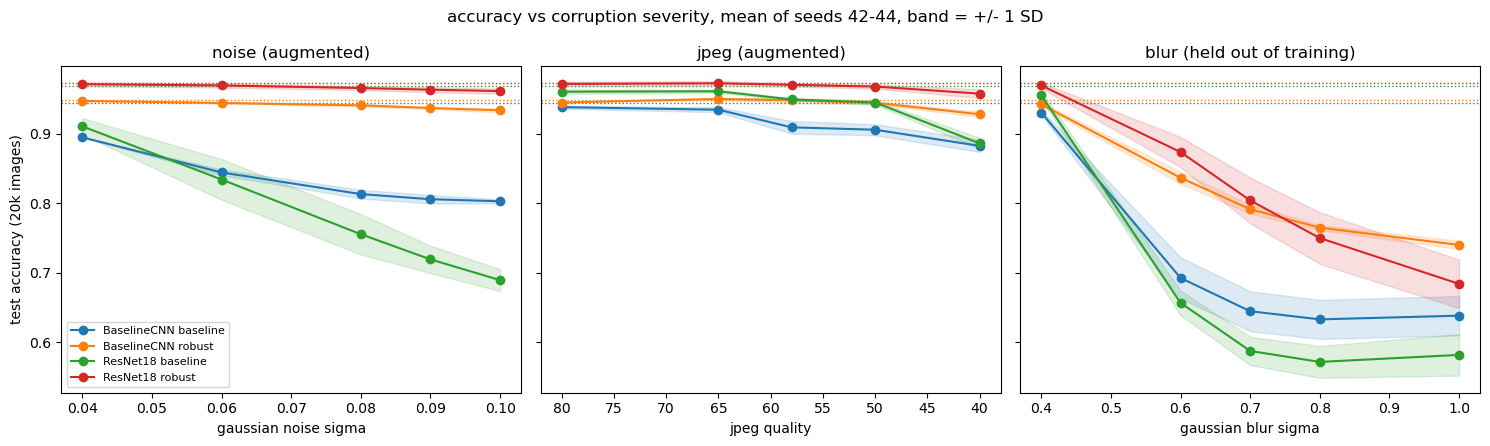

,model,condition,gap_mean,gap_sd,gap_min
0,BaselineCNN,clean,0.0049,0.0013,0.0036
1,BaselineCNN,noise 0.1,0.1309,0.0027,0.1280
2,BaselineCNN,jpeg 40,0.0455,0.0126,0.0363
3,BaselineCNN,blur 0.6,0.1442,0.0384,0.1021
4,BaselineCNN,blur 1,0.1018,0.0228,0.0768
5,ResNet18,clean,0.0039,0.0011,0.0027
6,ResNet18,noise 0.1,0.2722,0.0172,0.2524
7,ResNet18,jpeg 40,0.0716,0.0064,0.0645
8,ResNet18,blur 0.6,0.2171,0.0264,0.1867
9,ResNet18,blur 1,0.1022,0.0419,0.0544


all 30 paired gaps are positive: 5 conditions x 3 seeds x 2 architectures


In [13]:
#One figure for the report: accuracy against severity, four lines per panel
#(model x strategy), the held-out corruption on its own labelled panel.
line_colours = {
  ("BaselineCNN", "baseline"): "tab:blue",
  ("BaselineCNN", "robust"): "tab:orange",
  ("ResNet18", "baseline"): "tab:green",
  ("ResNet18", "robust"): "tab:red",
}
panels = [("noise", "noise (augmented)", "gaussian noise sigma"),
     ("jpeg", "jpeg (augmented)", "jpeg quality"),
     ("blur", "blur (held out of training)", "gaussian blur sigma")]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, (kind, title, xlabel) in zip(axes, panels):
  for (model, strategy), colour in line_colours.items():
    sub = (results[(results["model"] == model) & (results["strategy"] == strategy)
           & (results["corruption"] == kind)]
        .groupby("severity")["accuracy"].agg(["mean", "std"]).reset_index())
    ax.plot(sub["severity"], sub["mean"], marker="o", color=colour,
        label=f"{model} {strategy}")
    ax.fill_between(sub["severity"], sub["mean"] - sub["std"],
            sub["mean"] + sub["std"], color=colour, alpha=0.15)
    clean = results[(results["model"] == model) & (results["strategy"] == strategy)
            & (results["corruption"] == "none")]["accuracy"].mean()
    ax.axhline(clean, color=colour, linestyle=":", linewidth=1)
  if kind == "jpeg":
    ax.invert_xaxis()  #lower quality is harsher, so severity rises rightward like the other panels
  ax.set_title(title)
  ax.set_xlabel(xlabel)
axes[0].set_ylabel("test accuracy (20k images)")
axes[0].legend(fontsize=8)
fig.suptitle("accuracy vs corruption severity, mean of seeds 42-44, band = +/- 1 SD")
plt.tight_layout()
plt.show()

#Paired per-seed gaps at the headline severities. The augmentation claim
#rests on these being positive on every seed, not just on the 3-seed means.
gap_conditions = [("clean", "none", 0.0), ("noise 0.1", "noise", 0.10),
         ("jpeg 40", "jpeg", 40.0), ("blur 0.6", "blur", 0.6),
         ("blur 1", "blur", 1.0)]
gap_rows = []
n_positive = 0
for model in ["BaselineCNN", "ResNet18"]:
  for name, kind, sev in gap_conditions:
    sub = results[(results["model"] == model) & (results["corruption"] == kind)
           & (results["severity"] == sev)]
    gaps = (sub.pivot(index="seed", columns="strategy", values="accuracy")
        .eval("robust - baseline"))
    n_positive += int((gaps > 0).sum())
    gap_rows.append({"model": model, "condition": name,
             "gap_mean": round(gaps.mean(), 4),
             "gap_sd": round(gaps.std(), 4),
             "gap_min": round(gaps.min(), 4)})
display(pd.DataFrame(gap_rows))
assert n_positive == 30
print("all 30 paired gaps are positive: 5 conditions x 3 seeds x 2 architectures")


## What the numbers say

Augmentation transfers to the held-out corruption on both architectures. Averaged over the five blur severities, the robust models lead by 0.107 (CNN) and 0.146 (ResNet-18); at blur 0.6 the gaps are 0.144 and 0.217. Neither architecture pays for it on clean data (gaps of +0.005 and +0.004, each about twice its between-seed SD, so small but not negative).

Pretraining bought clean accuracy, not robustness. The baseline ResNet-18 beats the baseline CNN clean (0.969 against 0.944) yet collapses harder under every corruption it never saw; at noise 0.10 it holds 0.689 against the CNN's 0.803, and at blur 1.0 it drops to 0.582 against the CNN's 0.638. Augmentation more than closes the gap where it saw the corruption family (the robust ResNet-18 reaches 0.962 at noise 0.10 and 0.958 at jpeg 40) but only partly on held-out blur at the harshest severity, where the robust ResNet-18 (0.684) still trails the robust CNN (0.740).

The seed honesty check. All 30 paired robust-minus-baseline gaps (5 headline conditions, 3 seeds, 2 architectures) are positive, and in every condition but one the mean gap is several times the between-seed SD. The exception is the ResNet-18 at blur 1.0, where seed 42's gap of +0.054 sits close to the 0.042 SD; the direction is consistent across seeds but with three of them we would not lean on that one cell's magnitude.


## What carries to the report

The report takes three claims from this notebook. Corruption augmentation transfers to a held-out corruption on both a 544k-parameter CNN and an 11.2M-parameter pretrained ResNet-18, at no clean cost. ImageNet pretraining raises clean accuracy but leaves the unaugmented model more brittle, not less. Both effects exceed the 3-seed noise everywhere except the ResNet-18 blur 1.0 magnitude flagged above.

Limitations to state plainly. Three seeds bound the noise but do not eliminate it, the ResNet-18 keeps CIFAR-style normalisation and discards its pretrained stem, blur is a single held-out corruption family, and CIFAKE's fakes come from one generator (Stable Diffusion v1.4), so nothing here speaks to other generators. The ResNet-18 training provenance, including the atomic publication and quarantine machinery deliberately kept out of this notebook, lives in `resnet18_runner_COLAB.ipynb`.
